In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Чтобы графики отображались прямо в ноутбуке
%matplotlib inline

In [16]:
# Читаем файл из папки data
df = pd.read_csv('../data/Mall_Customers.csv')

# Посмотрим на первые 5 строк
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
import pandas as pd

In [18]:
# Выбираем признаки: Годовой доход и Рейтинг трат
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Масштабируем данные (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Проверим, что переменная создалась
print("Данные успешно масштабированы!")

Данные успешно масштабированы!


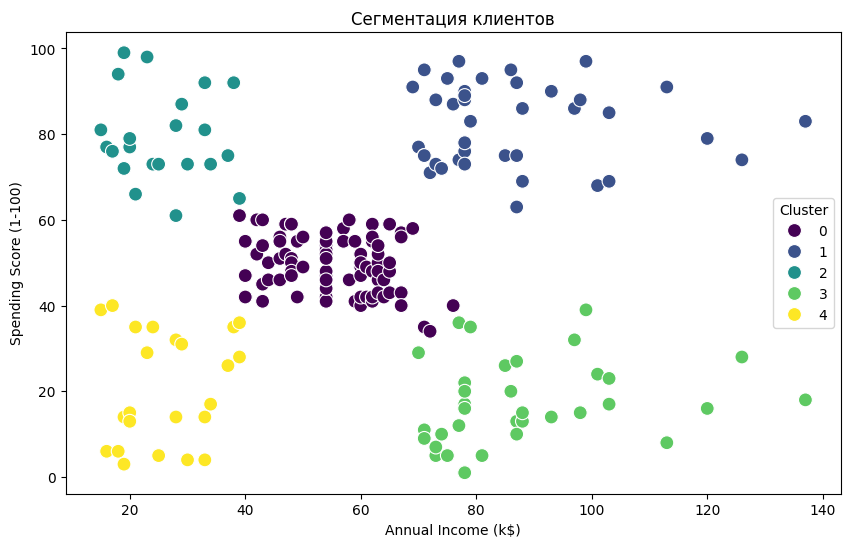

In [19]:
# Выбираем оптимальное количество кластеров (допустим, 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Визуализация результата
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100)
plt.title('Сегментация клиентов')
plt.show()

In [20]:
# Посмотрим на средние значения возраста, дохода и трат для каждого кластера
analysis = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(analysis)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
